In [7]:
import numpy as np
from io import StringIO
import glob

# proliferating e-anyons, m-anyons subthreshold

def load_error_rate(filename):
    """Read one output_*.txt file and return its 'Error Rate:' block as a 16x8 array."""
    with open(filename) as f:
        text = f.read()
    # grab everything between the "Error Rate:" header and the next blank line
    block = text.split("Error Rate:")[1].split("\n\n")[0]
    return np.loadtxt(StringIO(block))

# list the output files to combine (one file == one run)
files = sorted(glob.glob(
    "/Users/aubreyzhang/Documents/ILP_DATA/logicalXs/ILP_PE_X/pz_0_heralded_X/output_*.txt"))

# stack into the same shape as before: (n_files, 16, 8)
runs = np.stack([load_error_rate(f) for f in files])

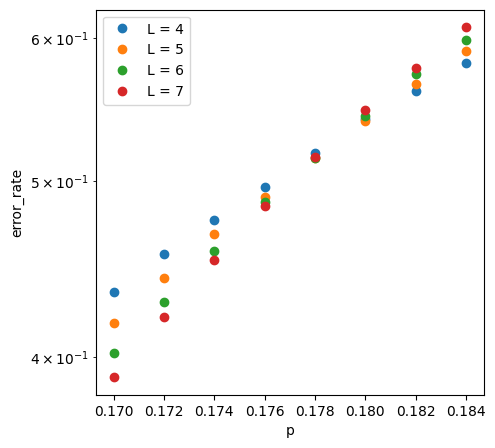

In [8]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

p = [0.17, 0.172, 0.174, 0.176, 0.178, 0.18, 0.182, 0.184]
L = [4, 5, 6, 7]

error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

plt.figure(figsize=(5, 5))
for l in range(len(L)):
    plt.plot(p, error_rate[l], 'o', label=f'L = {L[l]}')
    
plt.yscale('log')
plt.xlabel('p')
plt.ylabel('error_rate')
plt.legend()
plt.show()

In [9]:
from scipy.optimize import curve_fit

p = np.tile(np.array([0.17, 0.172, 0.174, 0.176, 0.178, 0.18, 0.182, 0.184]), 4)
L = np.repeat(np.array([4,5,6,7]), 8)
rate = error_rate.flatten()
n = 10000
rate_error = np.array([])
for i in range(len(p)):
    se = (rate[i]*(1-rate[i])/n)**(1/2)
    rate_error = np.append(rate_error, se)

In [10]:
# Define the model
def model(pL, pc, nu, A, B, C):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [ 0.17867397  1.40861161  0.52517444  3.93602213 -0.57669187]
Parameter standard deviations: [5.03929040e-04 1.45027872e-01 6.53482016e-03 5.01173949e-01
 4.04010211e+00]


np.float64(5.297744401737033)

In [11]:
# Define the model
def model(pL, pc, nu, A, B, C, D):
    p, L = pL
    return A + B*(p-pc)*(L**(1/nu)) + C*((p-pc)**2)*(L**(2/nu)) + D*((p-pc)**3)*(L**(3/nu))

# Perform the fit with error bars
popt, pcov, infodict, mesg, ier = curve_fit(model, (p, L), rate, p0=[0.2, 1.5, 0.25, 0, 0, 0], full_output=True, sigma=rate_error, absolute_sigma=True)

# Results
print("Fitted parameters:", popt)

# Calculate standard deviations of parameters
perr = np.sqrt(np.diag(pcov))
print("Parameter standard deviations:", perr)
np.sum(np.abs(infodict['fvec']))

Fitted parameters: [  0.17864654   1.38002543   0.52504536   3.87014674  -2.19470658
 -89.97900044]
Parameter standard deviations: [5.03337779e-04 1.64759696e-01 6.50751605e-03 5.37233724e-01
 5.90647286e+00 2.49058510e+02]


np.float64(5.267398698596957)

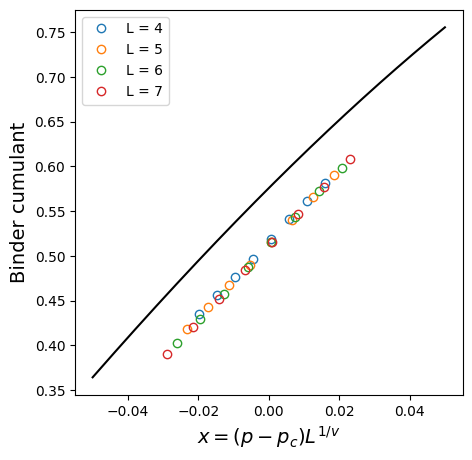

In [12]:
pc, nu, A, B, C, D=0.17678502,  1.48062075,  0.57579608,  3.94064893, -6.36998006, -9.67167559

p = [0.169, 0.171, 0.173, 0.175, 0.177, 0.179, 0.181, 0.183]
L = [4, 5, 6, 7]
error_rate = np.array([np.mean(runs[:, 0:4, :], axis=(0, 1)),
                       np.mean(runs[:, 4:8, :], axis=(0, 1)),
                       np.mean(runs[:, 8:12, :], axis=(0, 1)),
                       np.mean(runs[:, 12:16, :], axis=(0, 1))])

x = np.zeros((len(L), len(p)))
plt.figure(figsize=(5, 5))
for l in range(len(L)):
    for i in range(len(p)):
        x[l][i] = (p[i]-pc) * (L[l]**(1/nu))
    plt.plot(x[l], error_rate[l], 'o', markerfacecolor='none', label=f'L = {L[l]}')
x_data = np.linspace(-0.05, 0.05, 1000)
y_data = A + B*x_data + C*(x_data**2) +D*(x_data**3)
plt.plot(x_data, y_data, color = 'k')

#ax = plt.gca()
#ax.spines['top'].set_visible(False)
#ax.spines['right'].set_visible(False)

#plt.yscale('log')
plt.xlabel('$x=(p-p_c)L^{1/v}$', fontsize=14)
plt.ylabel('Binder cumulant', fontsize=14)
plt.legend()
#plt.savefig('modified-D4.png', dpi=600, bbox_inches='tight')
plt.show()